In [9]:
# perform simple linear regression and predict the exam scores of the bca students 
# with both libraries and math formulae

In [10]:
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression as LR
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import root_mean_squared_error as RMSE

In [11]:
def median(data):
    data=deepcopy(data)
    N=len(data)
    if N//2:
        median=(data[N//2+1]+data[N//2])/2
    else:
        median=(data[(N+1)//2])
    return median

def M(data,k): #kth central moment
    # central moments has lots of use,
    # for example: (--> means related to)
    # k=0-->total
    # k=1-->mean, k=2-->variance
    # k=3-->skewness, k=4-->kurtosis
    data=deepcopy(data)
    Mk=0
    for i in data:
        Mk+=(i)**k
    return Mk

In [12]:
# no need for any path since the csv files is already right a branch file of chius
df = pd.read_csv("Example to regressions.csv")
df_init=df.head(200)[df['course']=='b.sc']
#df_init=df
N=df_init.shape[0]
df_init

C:\Users\chius\AppData\Local\Temp\ipykernel_16016\4198037210.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_init=df.head(200)[df['course']=='b.sc']


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
7,8,22,male,b.sc,5.48,51.1,yes,8.2,poor,self-study,low,moderate,47.3
16,17,21,male,b.sc,1.97,91.9,yes,8.3,average,self-study,medium,moderate,70.3
18,19,23,female,b.sc,4.28,98.1,yes,4.4,average,mixed,low,moderate,56.2
28,29,21,female,b.sc,2.72,79.4,yes,7.0,good,online videos,medium,moderate,56.6
31,32,18,male,b.sc,5.78,66.1,yes,5.1,good,self-study,high,easy,81.8
36,37,23,female,b.sc,0.12,43.2,no,5.8,average,online videos,medium,hard,37.3
44,45,17,other,b.sc,0.75,72.0,yes,5.1,average,group study,medium,moderate,42.8
45,46,24,male,b.sc,7.83,67.8,yes,7.8,good,coaching,high,easy,100.0
48,49,22,female,b.sc,0.90,74.5,yes,5.5,poor,mixed,high,moderate,30.9


In [13]:
# student no. 48, class attendance
df["class_attendance"].loc[48]

np.float64(74.5)

In [14]:
parameter={'gender':{'male':1.0,'female':2.0,'other':3.0},
           'internet_access':{'yes':1.0,'no':0.0},
           'sleep_quality':{'poor':1.0,'average':2.0,'good':3.0},
           'facility_rating':{'low':1.0,'medium':2.0,'high':3.0},
           'exam_difficulty':{'easy':3.0,'moderate':2.0,'hard':1.0}}

In [15]:
df_reg=df_init.drop(columns=['course','study_method'],errors='ignore').replace(parameter)
df_reg

C:\Users\chius\AppData\Local\Temp\ipykernel_16016\3855208574.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_reg=df_init.drop(columns=['course','study_method'],errors='ignore').replace(parameter)


,student_id,age,gender,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,facility_rating,exam_difficulty,exam_score
2,3,22,1.0,7.88,76.8,1.0,8.5,1.0,3.0,2.0,90.3
7,8,22,1.0,5.48,51.1,1.0,8.2,1.0,1.0,2.0,47.3
16,17,21,1.0,1.97,91.9,1.0,8.3,2.0,2.0,2.0,70.3
18,19,23,2.0,4.28,98.1,1.0,4.4,2.0,1.0,2.0,56.2
28,29,21,2.0,2.72,79.4,1.0,7.0,3.0,2.0,2.0,56.6
31,32,18,1.0,5.78,66.1,1.0,5.1,3.0,3.0,3.0,81.8
36,37,23,2.0,0.12,43.2,0.0,5.8,2.0,2.0,1.0,37.3
44,45,17,3.0,0.75,72.0,1.0,5.1,2.0,2.0,2.0,42.8
45,46,24,1.0,7.83,67.8,1.0,7.8,3.0,3.0,3.0,100.0
48,49,22,2.0,0.90,74.5,1.0,5.5,1.0,3.0,2.0,30.9


In [16]:
print(df_reg['exam_score'].min())

30.9


In [17]:
df_reg.corr()['exam_score']

student_id         -0.002692
age                -0.049098
gender             -0.226739
study_hours         0.759054
class_attendance    0.319364
internet_access     0.236304
sleep_hours         0.245498
sleep_quality      -0.011713
facility_rating     0.109882
exam_difficulty     0.057540
exam_score          1.000000
Name: exam_score, dtype: float64

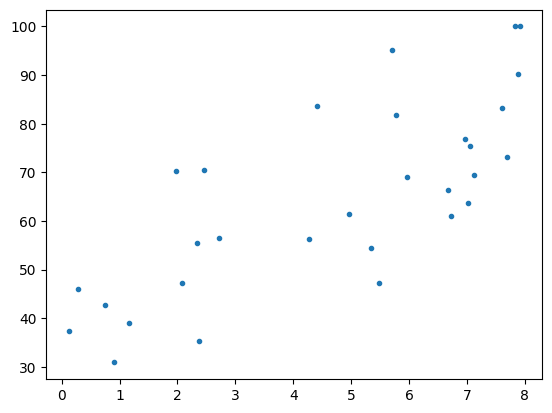

In [18]:
# graph of most important factor (study_hours) against output (exam_score)
fig=plt.figure()
ax=fig.add_subplot(111)
ax.plot(df_reg['study_hours'],df_reg['exam_score'],'.')
plt.show()

In [19]:
df_np=df_reg.to_numpy()

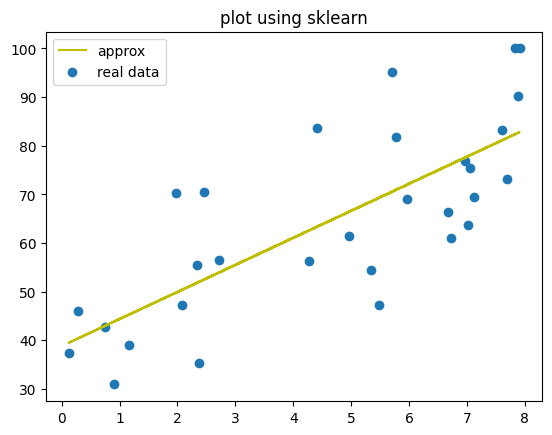

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
input1='study_hours'
output='exam_score'

X_train,y_train=df_reg[input1],df_reg[output]

#library
linre=LR().fit(X_train.to_numpy().reshape((N,1)),y_train)
m,c=linre.coef_,linre.intercept_
yapprox=(m*df_reg[input1]+c).to_numpy()
fig=plt.figure()
ax=fig.add_subplot(111)
ax.plot(df_reg[input1],yapprox,'y',label='approx')
ax.scatter(df_reg[input1],df_reg[output],label='real data')
ax.set_title('plot using sklearn')
ax.legend()
plt.show()
linre

In [21]:
print(RMSE(df_reg['exam_score'],yapprox))

12.311967511032403


In [22]:
approx_df=pd.DataFrame({'study_hour':df_np[:,3],
                        'exam_results_data':df_np[:,-1],
                        'exam_approx_lib':yapprox})
approx_df

,study_hour,exam_results_data,exam_approx_lib
0,7.88,90.3,82.630299
1,5.48,47.3,69.282152
2,1.97,70.3,49.760486
3,4.28,56.2,62.608078
4,2.72,56.6,53.931782
5,5.78,81.8,70.950670
6,0.12,37.3,39.471289
7,0.75,42.8,42.975178
8,7.83,100.0,82.352213
9,0.90,30.9,43.809437


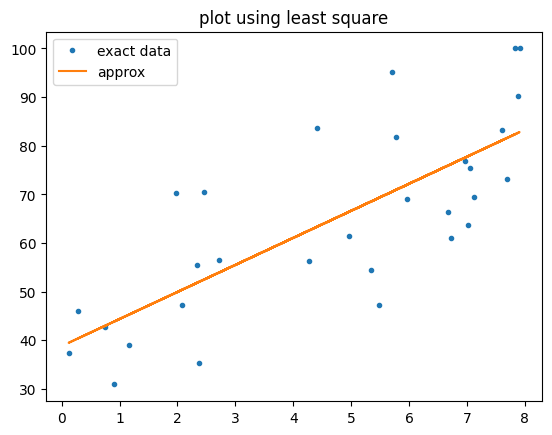

In [23]:
# the linear fit (simple linear regression)

y=df_reg[output]
meany=M(y,1)/N
x=df_reg[input1]
meanx=M(x,1)/N
varx=M(x-meanx*np.ones(N),2)/N

m=M((y-meany*np.ones(N))*(x-meanx*np.ones(N)),1)
m/=varx*N
c=meany-m*meanx
yapprox=m*x+c

fig=plt.figure()
ax=fig.add_subplot(111)
ax.plot(x,y,'.',label='exact data')
ax.plot(x,yapprox,label='approx')
ax.set_title('plot using least square')
ax.legend()
plt.show()

In [24]:
pd.DataFrame({'study_hour':df_reg['study_hours'],
              'exam_score':df_reg['exam_score'],
              'exam_approx_maths':yapprox})

,study_hour,exam_score,exam_approx_maths
2,7.88,90.3,82.630299
7,5.48,47.3,69.282152
16,1.97,70.3,49.760486
18,4.28,56.2,62.608078
28,2.72,56.6,53.931782
31,5.78,81.8,70.950670
36,0.12,37.3,39.471289
44,0.75,42.8,42.975178
45,7.83,100.0,82.352213
48,0.90,30.9,43.809437
